# Weibull vs Log-Normal AFT: Bayesian and Frequentist Comparison

Comparing four model fits on a 70/30 stratified train/test split of the Anderson leukemia dataset.

| Model | Family | Library |
|---|---|---|
| Weibull AFT | Weibull | `lifelines.WeibullAFTFitter` |
| Log-Normal AFT | Log-Normal | `lifelines.LogNormalAFTFitter` |
| Weibull AFT | Weibull | `bayes_survival.WeibullAFTModel` (PyMC) |
| Log-Normal AFT | Log-Normal | `bayes_survival.LogNormalAFTModel` (PyMC) |

**Comparisons:**
1. Covariate coefficients (point estimates + uncertainty intervals)
2. Survival functions on test-set individuals
3. Predicted event time distributions (lifelines median vs Bayesian posterior predictive)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az

from lifelines import WeibullAFTFitter, LogNormalAFTFitter
from lifelines.datasets import load_leukemia

from bayes_survival.survival_models.aft import WeibullAFTModel, LogNormalAFTModel
from bayes_survival.nonparametric import KaplanMeierModel

plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})
az.style.use('arviz-white')

In [2]:
df = load_leukemia()
feature_cols = ['sex', 'logWBC', 'Rx']

# Stratified 70/30 split on event status (no sklearn dependency)
rng = np.random.default_rng(42)
event_idx    = np.where(df['status'].values == 1)[0]
censored_idx = np.where(df['status'].values == 0)[0]

n_test_ev = int(round(len(event_idx)    * 0.3))
n_test_ce = int(round(len(censored_idx) * 0.3))

test_ev  = rng.choice(event_idx,    n_test_ev, replace=False)
test_ce  = rng.choice(censored_idx, n_test_ce, replace=False)
test_idx = np.sort(np.concatenate([test_ev, test_ce]))
train_idx = np.setdiff1d(np.arange(len(df)), test_idx)

df_train = df.iloc[train_idx].reset_index(drop=True)
df_test  = df.iloc[test_idx].reset_index(drop=True)

X_train     = df_train[feature_cols].values
t_train     = df_train['t'].values.astype(float)
event_train = df_train['status'].values.astype(int)

X_test     = df_test[feature_cols].values
t_test     = df_test['t'].values.astype(float)
event_test = df_test['status'].values.astype(int)

print(f'Train: {len(df_train)} obs, {event_train.sum()} events ({event_train.mean():.1%})')
print(f'Test:  {len(df_test)} obs,  {event_test.sum()} events ({event_test.mean():.1%})')
df_test[feature_cols + ['t', 'status']]

Train: 29 obs, 21 events (72.4%)
Test:  13 obs,  9 events (69.2%)


,sex,logWBC,Rx,t,status
0,1,1.47,0,34,0
1,1,1.78,0,25,0
2,1,2.32,0,22,1
3,0,2.05,0,19,0
4,1,3.60,0,16,1
5,0,2.60,0,11,0
6,0,2.31,0,6,1
7,0,2.73,1,22,1
8,0,2.95,1,17,1
9,0,3.49,1,11,1


In [3]:
wbl_ll = WeibullAFTFitter()
wbl_ll.fit(df_train, duration_col='t', event_col='status')

lgn_ll = LogNormalAFTFitter()
lgn_ll.fit(df_train, duration_col='t', event_col='status')

print('lifelines Weibull AFT:')
wbl_ll.print_summary()
print('\nlifelines Log-Normal AFT:')
lgn_ll.print_summary()

lifelines Weibull AFT:


<lifelines.WeibullAFTFitter: fitted with 29 total observations, 8 right-censored observations>
             duration col = 't'
                event col = 'status'
   number of observations = 29
number of events observed = 21
           log-likelihood = -56.83
         time fit was run = 2026-03-30 05:18:07 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                  
lambda_ Rx        -0.91      0.40      0.20           -1.31           -0.51                0.27                0.60
        logWBC    -0.79      0.45      0.09           -0.97           -0.61                0.38                0.54
        sex       -0.03      0.97      0.18           -0.37            0.32                0.69                1.38
        Intercept  5.35    211.43      0.34            4.69            6.02              108.54              411.84
rho_    Intercept  0.92      2.52      0.17            0.58            1.27                1.79                3.54

                   cmp to     z      p  -log2(p)
param   covariate                               
lambda_ Rx           0.00 -4.47 <0.005     16.94
        logWBC       0.00 -8.64 <0.005     57.27
        sex          0.00 -0.15   0.88      0.19
        Intercept    0.00 15.74 <0.005    182.98
rho_    Intercept    0.00  5.29 <0.005     22.93
---
Concordance = 0.89
AIC = 123.67
log-likelihood ratio test = 44.99 on 3 df
-log2(p) of ll-ratio test = 30.00


lifelines Log-Normal AFT:


<lifelines.LogNormalAFTFitter: fitted with 29 total observations, 8 right-censored observations>
             duration col = 't'
                event col = 'status'
   number of observations = 29
number of events observed = 21
           log-likelihood = -59.80
         time fit was run = 2026-03-30 05:18:07 UTC

---
                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                  
mu_    Rx        -1.10      0.33      0.25           -1.59           -0.61                0.20                0.55
       logWBC    -0.73      0.48      0.13           -0.98           -0.48                0.38                0.62
       sex       -0.07      0.93      0.24           -0.55            0.41                0.58                1.51
       Intercept  5.08    160.56      0.42            4.25            5.91               70.09              367.81
sigma_ Intercept -0.53      0.59      0.15           -0.84           -0.23                0.43                0.79

                  cmp to     z      p  -log2(p)
param  covariate                               
mu_    Rx           0.00 -4.38 <0.005     16.37
       logWBC       0.00 -5.80 <0.005     27.14
       sex          0.00 -0.28   0.78      0.36
       Intercept    0.00 12.01 <0.005    107.96
sigma_ Intercept    0.00 -3.47 <0.005     10.88
---
Concordance = 0.89
AIC = 129.59
log-likelihood ratio test = 36.75 on 3 df
-log2(p) of ll-ratio test = 24.20

In [4]:
wbl_bay = WeibullAFTModel()
wbl_bay.fit(
    X_train, t_train, event_train,
    draws=1000, tune=1000, chains=4,
    target_accept=0.99, random_seed=42,
)
az.summary(wbl_bay.idata, var_names=['alpha', 'beta'], hdi_prob=0.95)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 19 seconds.


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,2.249,0.398,1.472,3.022,0.009,0.007,1898.0,2053.0,1.0
beta[0],5.399,0.404,4.631,6.220,0.010,0.007,1780.0,1745.0,1.0
beta[1],0.004,0.215,-0.393,0.450,0.004,0.004,2613.0,2248.0,1.0
beta[2],-0.788,0.109,-1.004,-0.580,0.002,0.002,1965.0,1991.0,1.0
beta[3],-0.968,0.246,-1.446,-0.482,0.005,0.004,2105.0,1995.0,1.0


In [5]:
lgn_bay = LogNormalAFTModel()
lgn_bay.fit(
    X_train, t_train, event_train,
    draws=1000, tune=1000, chains=4,
    target_accept=0.99, random_seed=42,
)
az.summary(lgn_bay.idata, var_names=['sigma', 'beta'], hdi_prob=0.95)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, beta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 17 seconds.


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.762,0.148,0.496,1.046,0.003,0.002,2061.0,2533.0,1.0
beta[0],5.234,0.550,4.136,6.240,0.015,0.011,1372.0,1858.0,1.0
beta[1],-0.026,0.331,-0.692,0.604,0.007,0.006,2393.0,1948.0,1.0
beta[2],-0.759,0.165,-1.058,-0.415,0.004,0.003,1396.0,1523.0,1.0
beta[3],-1.193,0.327,-1.818,-0.550,0.007,0.005,2625.0,2140.0,1.0


## 1. Coefficient Comparison

We compare log-scale covariate coefficients (Î²) and the dispersion/shape parameter across all four models.

**Parameterisation notes:**
- **Weibull**: `Î» = exp(XÎ²)` is the scale; `Î±` is the shape. lifelines stores `log(Î±)` in `rho_/Intercept`.
- **Log-Normal**: `Î¼ = XÎ²` is the log-mean; `Ïƒ` is the spread. lifelines stores `log(Ïƒ)` in `sigma_/Intercept`.

Both families share the same `Î²` interpretation: positive `Î²_j` â†’ longer expected survival time.

In [6]:
wbl_ll_sum = wbl_ll.summary
lgn_ll_sum = lgn_ll.summary

# CI column names (robust to lifelines version differences)
def get_ci_cols(summary):
    lower = next(c for c in summary.columns if 'lower' in c and 'exp' not in c)
    upper = next(c for c in summary.columns if 'upper' in c and 'exp' not in c)
    return lower, upper

wbl_lo, wbl_hi = get_ci_cols(wbl_ll_sum)
lgn_lo, lgn_hi = get_ci_cols(lgn_ll_sum)

wbl_bay_sum = az.summary(wbl_bay.idata, var_names=['alpha', 'beta'], hdi_prob=0.95)
lgn_bay_sum = az.summary(lgn_bay.idata, var_names=['sigma', 'beta'], hdi_prob=0.95)

cov_names = ['Intercept', 'sex', 'logWBC', 'Rx']
bay_keys  = ['beta[0]', 'beta[1]', 'beta[2]', 'beta[3]']

rows = []
for cov, bk in zip(cov_names, bay_keys):
    wbl_r = wbl_ll_sum.loc[('lambda_', cov)]
    lgn_r = lgn_ll_sum.loc[('mu_', cov)]
    b_wbl = wbl_bay_sum.loc[bk]
    b_lgn = lgn_bay_sum.loc[bk]
    rows.append({
        'Covariate':           cov,
        'Weibull lifelines':   f"{wbl_r['coef']:.3f}  [{wbl_r[wbl_lo]:.3f}, {wbl_r[wbl_hi]:.3f}]",
        'Weibull Bayes':       f"{b_wbl['mean']:.3f}  [{b_wbl['hdi_2.5%']:.3f}, {b_wbl['hdi_97.5%']:.3f}]",
        'LogNormal lifelines': f"{lgn_r['coef']:.3f}  [{lgn_r[lgn_lo]:.3f}, {lgn_r[lgn_hi]:.3f}]",
        'LogNormal Bayes':     f"{b_lgn['mean']:.3f}  [{b_lgn['hdi_2.5%']:.3f}, {b_lgn['hdi_97.5%']:.3f}]",
    })

# Shape / dispersion parameters (alpha for Weibull, sigma for LogNormal)
wbl_rho = wbl_ll_sum.loc[('rho_',   'Intercept')]
lgn_sig = lgn_ll_sum.loc[('sigma_', 'Intercept')]
b_alpha = wbl_bay_sum.loc['alpha']
b_sigma = lgn_bay_sum.loc['sigma']
rows.append({
    'Covariate':           'alpha / sigma',
    'Weibull lifelines':   f"{np.exp(wbl_rho['coef']):.3f}  [{np.exp(wbl_rho[wbl_lo]):.3f}, {np.exp(wbl_rho[wbl_hi]):.3f}]",
    'Weibull Bayes':       f"{b_alpha['mean']:.3f}  [{b_alpha['hdi_2.5%']:.3f}, {b_alpha['hdi_97.5%']:.3f}]",
    'LogNormal lifelines': f"{np.exp(lgn_sig['coef']):.3f}  [{np.exp(lgn_sig[lgn_lo]):.3f}, {np.exp(lgn_sig[lgn_hi]):.3f}]",
    'LogNormal Bayes':     f"{b_sigma['mean']:.3f}  [{b_sigma['hdi_2.5%']:.3f}, {b_sigma['hdi_97.5%']:.3f}]",
})

pd.DataFrame(rows).set_index('Covariate')

,Weibull lifelines,Weibull Bayes,LogNormal lifelines,LogNormal Bayes
Covariate,,,,
Intercept,"5.354 [4.687, 6.021]","5.399 [4.631, 6.220]","5.079 [4.250, 5.908]","5.234 [4.136, 6.240]"
sex,"-0.027 [-0.375, 0.320]","0.004 [-0.393, 0.450]","-0.069 [-0.549, 0.410]","-0.026 [-0.692, 0.604]"
logWBC,"-0.794 [-0.975, -0.614]","-0.788 [-1.004, -0.580]","-0.732 [-0.980, -0.485]","-0.759 [-1.058, -0.415]"
Rx,"-0.909 [-1.307, -0.510]","-0.968 [-1.446, -0.482]","-1.098 [-1.589, -0.607]","-1.193 [-1.818, -0.550]"
alpha / sigma,"2.517 [1.787, 3.545]","2.249 [1.472, 3.022]","0.586 [0.433, 0.793]","0.762 [0.496, 1.046]"


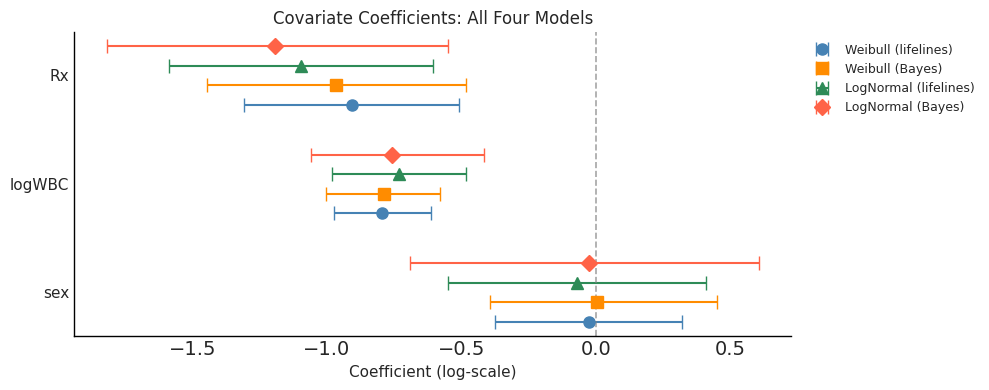

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))

cov_plot     = ['sex', 'logWBC', 'Rx']
bay_keys_plt = ['beta[1]', 'beta[2]', 'beta[3]']
y_pos    = np.arange(len(cov_plot))
offsets  = [-0.27, -0.09, 0.09, 0.27]
colors   = ['steelblue', 'darkorange', 'seagreen', 'tomato']
markers  = ['o', 's', '^', 'D']
labels   = ['Weibull (lifelines)', 'Weibull (Bayes)', 'LogNormal (lifelines)', 'LogNormal (Bayes)']

for i, (cov, bk) in enumerate(zip(cov_plot, bay_keys_plt)):
    wbl_r = wbl_ll_sum.loc[('lambda_', cov)]
    lgn_r = lgn_ll_sum.loc[('mu_', cov)]
    b_wbl = wbl_bay_sum.loc[bk]
    b_lgn = lgn_bay_sum.loc[bk]

    estimates = [
        (wbl_r['coef'],   wbl_r[wbl_lo],      wbl_r[wbl_hi]),
        (b_wbl['mean'],   b_wbl['hdi_2.5%'],   b_wbl['hdi_97.5%']),
        (lgn_r['coef'],   lgn_r[lgn_lo],       lgn_r[lgn_hi]),
        (b_lgn['mean'],   b_lgn['hdi_2.5%'],   b_lgn['hdi_97.5%']),
    ]

    for j, (est, lo, hi) in enumerate(estimates):
        ax.errorbar(
            est, y_pos[i] + offsets[j],
            xerr=[[est - lo], [hi - est]],
            fmt=markers[j], color=colors[j], ms=8, capsize=5, lw=1.5,
            label=labels[j] if i == 0 else '',
        )

ax.axvline(0, color='grey', linestyle='--', lw=1.2, alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(cov_plot, fontsize=11)
ax.set_xlabel('Coefficient (log-scale)', fontsize=11)
ax.set_title('Covariate Coefficients: All Four Models', fontsize=12)
ax.legend(fontsize=9, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 2. Survival Functions on Test-Set Individuals

Four test-set individuals are selected by sorting on treatment group (`Rx`) then `logWBC`, spanning the covariate space from best to worst prognosis. Each subplot shows:

- **Solid / dashed lines** â€” lifelines MLE curves (Weibull blue, Log-Normal green)
- **Shaded regions** â€” Bayesian 95% HDI (Weibull orange, Log-Normal red)
- **Dotted vertical line** â€” individual's actual observed time; `Ã—` = event occurred, `â—‹` = censored

In [8]:
# Sort test set to span covariate space; preserve df_test index (= position in X_test)
test_sorted = df_test.sort_values(['Rx', 'logWBC'])
n_test = len(test_sorted)
sel_pos = [0, n_test // 3, 2 * n_test // 3, n_test - 1]
selected = test_sorted.iloc[sel_pos]   # .index values = positions in df_test / X_test

print('Selected test individuals (index = row position in df_test / X_test):')
print(selected[['sex', 'logWBC', 'Rx', 't', 'status']].round(3).to_string())

Selected test individuals (index = row position in df_test / X_test):
    sex  logWBC  Rx   t  status
0     1    1.47   0  34       0
2     1    2.32   0  22       1
8     0    2.95   1  17       1
12    1    4.36   1   4       1


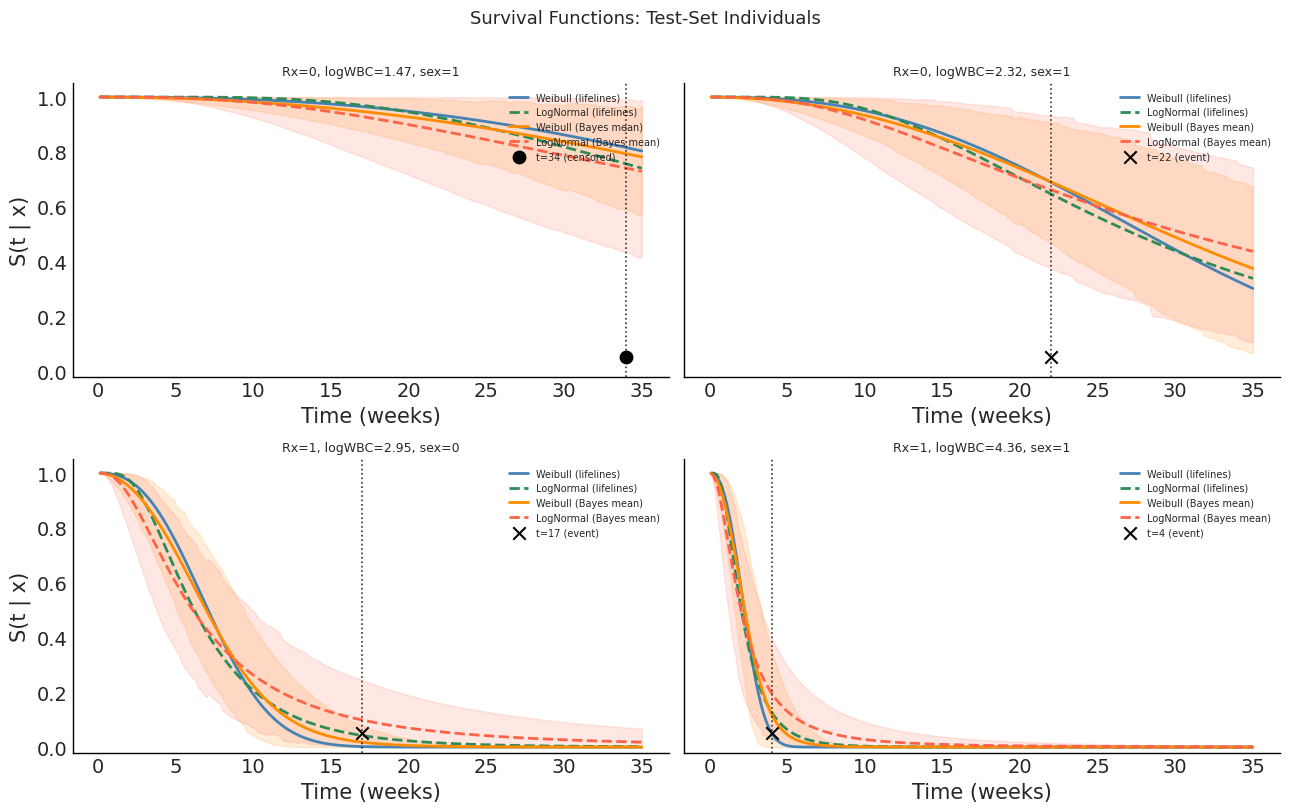

In [9]:
eval_times = np.linspace(0.1, df['t'].max(), 200)

surv_wbl_ll = wbl_ll.predict_survival_function(selected, times=eval_times)
surv_lgn_ll = lgn_ll.predict_survival_function(selected, times=eval_times)

X_sel    = selected[feature_cols].values
pred_wbl = wbl_bay.predict_survival_function(X_sel, eval_times, hdi_prob=0.95)
pred_lgn = lgn_bay.predict_survival_function(X_sel, eval_times, hdi_prob=0.95)

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey=True)
axes = axes.flatten()

for idx, (ax, (df_idx, row)) in enumerate(zip(axes, selected.iterrows())):
    # lifelines
    ax.plot(eval_times, surv_wbl_ll.iloc[:, idx],
            color='steelblue', lw=2, label='Weibull (lifelines)')
    ax.plot(eval_times, surv_lgn_ll.iloc[:, idx],
            color='seagreen', lw=2, ls='--', label='LogNormal (lifelines)')

    # Bayesian mean + HDI
    ax.plot(eval_times, pred_wbl.mean[idx],
            color='darkorange', lw=2, label='Weibull (Bayes mean)')
    ax.fill_between(eval_times, pred_wbl.hdi_lower[idx], pred_wbl.hdi_upper[idx],
                    color='darkorange', alpha=0.15)
    ax.plot(eval_times, pred_lgn.mean[idx],
            color='tomato', lw=2, ls='--', label='LogNormal (Bayes mean)')
    ax.fill_between(eval_times, pred_lgn.hdi_lower[idx], pred_lgn.hdi_upper[idx],
                    color='tomato', alpha=0.15)

    # Actual observed time
    marker_style = 'x' if row['status'] == 1 else 'o'
    status_label = 'event' if row['status'] == 1 else 'censored'
    ax.axvline(row['t'], color='black', lw=1.2, ls=':', alpha=0.8)
    ax.scatter([row['t']], [0.05], color='black', marker=marker_style,
               s=80, zorder=5, label=f"t={row['t']:.0f} ({status_label})")

    ax.set_title(f"Rx={int(row['Rx'])}, logWBC={row['logWBC']:.2f}, sex={int(row['sex'])}",
                 fontsize=9)
    ax.set_xlabel('Time (weeks)')
    ax.set_ylim(-0.02, 1.05)
    if idx % 2 == 0:
        ax.set_ylabel('S(t | x)')
    ax.legend(fontsize=7, loc='upper right')

plt.suptitle('Survival Functions: Test-Set Individuals', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 3. Bayesian Kaplan-Meier Baseline

Before comparing parametric models, we fit a nonparametric baseline using the
**Beta-Binomial conjugate Kaplan-Meier** estimator.
At each observed event time t_j the conditional hazard h_j receives an independent
Beta(1, 1) prior (Uniform); the posterior is Beta(1 + d_j, 1 + n_j - d_j) in closed form
— no MCMC required.

The shaded band is a 95 % HDI obtained by sampling survival curves
S(t) = ∏_{t_j ≤ t} (1 − h_j) from the posterior.
The dashed line is the analytical posterior-mean survival curve.

In [ ]:
km_bay = KaplanMeierModel()   # Beta(1, 1) uniform prior on each conditional hazard
km_bay.fit(t_train, event_train)

km_times, km_mean_analytical = km_bay.posterior_mean_survival
pred_km = km_bay.predict_survival_function(eval_times, hdi_prob=0.95)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(eval_times, pred_km.mean[0], lw=2, color='C0', label='Posterior mean (sampled)')
ax.fill_between(
    eval_times, pred_km.hdi_lower[0], pred_km.hdi_upper[0],
    alpha=0.25, color='C0', label='95% HDI'
)
ax.step(
    np.concatenate([[0], km_times]),
    np.concatenate([[1], km_mean_analytical]),
    where='post', lw=1.5, ls='--', color='k', label='Analytical posterior mean'
)

ax.set_xlabel('Time')
ax.set_ylabel('S(t)')
ax.set_title('Bayesian Kaplan-Meier — training data (Beta-Binomial conjugate)')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Predicted Event Times

**lifelines**: `predict_median()` returns a single point estimate â€” the median event time from the fitted parametric distribution.

**Bayesian**: `sample_predicted_event_times()` draws from the posterior predictive distribution using `pm.sample_posterior_predictive` with `upper=inf` (removing censoring), returning a full distribution of plausible event times per individual.

The violin plots show the Bayesian posterior predictive distributions; diamond markers show the lifelines median; the horizontal line shows the actual observed time (solid = event, dashed = censored).

In [10]:
X_test_df = df_test[feature_cols]

# lifelines: parametric median event time (point estimate)
med_wbl_ll = wbl_ll.predict_median(X_test_df)
med_lgn_ll = lgn_ll.predict_median(X_test_df)

# Bayesian: posterior predictive samples â€” shape (n_samples, n_test)
samp_wbl = wbl_bay.sample_predicted_event_times(X_test)
samp_lgn = lgn_bay.sample_predicted_event_times(X_test)

print(f'PPD shape â€” Weibull: {samp_wbl.shape},  LogNormal: {samp_lgn.shape}')

Sampling: [obs]


Output()

Sampling: [obs]


Output()

PPD shape â€” Weibull: (4000, 13),  LogNormal: (4000, 13)


In [11]:
rows_et = []
for idx, (df_idx, row) in enumerate(selected.iterrows()):
    w_s = samp_wbl[:, df_idx]
    l_s = samp_lgn[:, df_idx]
    rows_et.append({
        'Individual':                  f"Rx={int(row['Rx'])}, logWBC={row['logWBC']:.2f}",
        'Observed':                    f"{row['t']:.0f} ({'event' if row['status']==1 else 'censored'})",
        'Weibull lifelines median':    f"{float(med_wbl_ll.iloc[df_idx]):.1f}",
        'LogNormal lifelines median':  f"{float(med_lgn_ll.iloc[df_idx]):.1f}",
        'Weibull Bayes [95% HDI]':     f"{np.median(w_s):.1f}  [{np.percentile(w_s, 2.5):.1f}, {np.percentile(w_s, 97.5):.1f}]",
        'LogNormal Bayes [95% HDI]':   f"{np.median(l_s):.1f}  [{np.percentile(l_s, 2.5):.1f}, {np.percentile(l_s, 97.5):.1f}]",
    })

pd.DataFrame(rows_et).set_index('Individual')

,Observed,Weibull lifelines median,LogNormal lifelines median,Weibull Bayes [95% HDI],LogNormal Bayes [95% HDI]
Individual,,,,,
"Rx=0, logWBC=1.47",34 (censored),55.3,51.1,"57.4 [12.9, 163.5]","57.7 [10.4, 386.8]"
"Rx=0, logWBC=2.32",22 (event),28.2,27.4,"29.1 [6.0, 78.0]","31.0 [5.9, 186.2]"
"Rx=1, logWBC=2.95",17 (event),7.1,6.2,"7.0 [1.3, 15.9]","6.2 [1.3, 29.7]"
"Rx=1, logWBC=4.36",4 (event),2.2,2.1,"2.3 [0.5, 5.8]","2.1 [0.4, 10.4]"


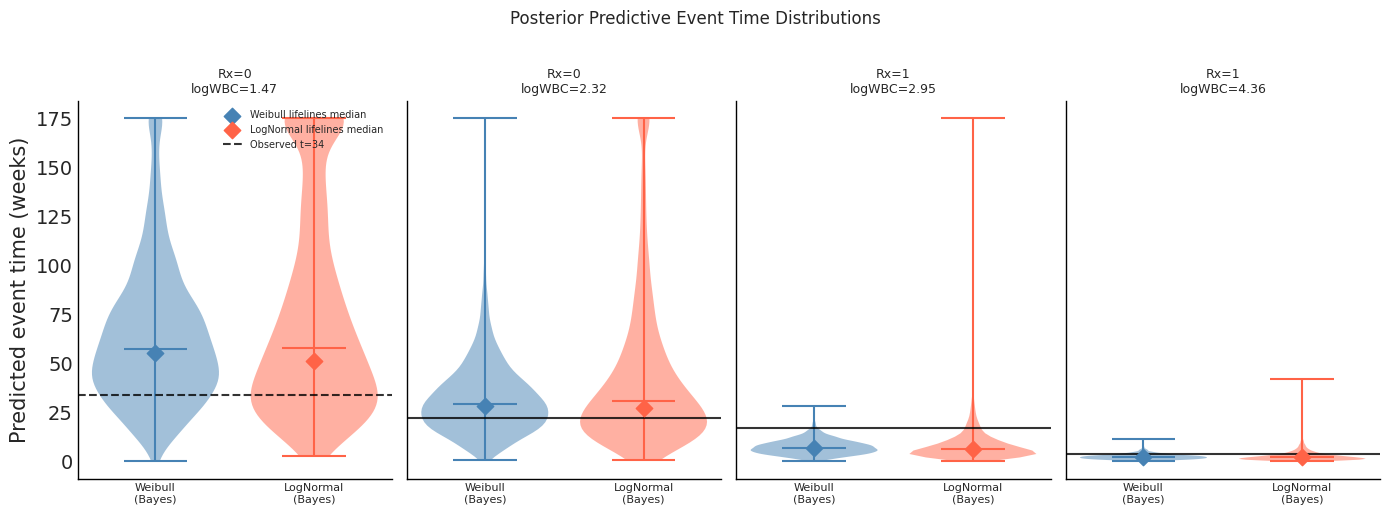

In [12]:
clip_val = df['t'].max() * 5   # clip extreme tails for readable violins

fig, axes = plt.subplots(1, 4, figsize=(14, 5), sharey=True)

for plot_i, (ax, (df_idx, row)) in enumerate(zip(axes, selected.iterrows())):
    w_i = np.clip(samp_wbl[:, df_idx], 0, clip_val)
    l_i = np.clip(samp_lgn[:, df_idx], 0, clip_val)

    vp_w = ax.violinplot(w_i, positions=[0.75], widths=0.4, showmedians=True)
    vp_l = ax.violinplot(l_i, positions=[1.25], widths=0.4, showmedians=True)

    for pc in vp_w['bodies']:
        pc.set_facecolor('steelblue'); pc.set_alpha(0.5)
    for part in ['cmedians', 'cbars', 'cmaxes', 'cmins']:
        vp_w[part].set_color('steelblue')
    for pc in vp_l['bodies']:
        pc.set_facecolor('tomato'); pc.set_alpha(0.5)
    for part in ['cmedians', 'cbars', 'cmaxes', 'cmins']:
        vp_l[part].set_color('tomato')

    # lifelines medians as diamond markers
    ax.scatter(0.75, float(med_wbl_ll.iloc[df_idx]), color='steelblue',
               marker='D', s=70, zorder=5,
               label='Weibull lifelines median' if plot_i == 0 else '')
    ax.scatter(1.25, float(med_lgn_ll.iloc[df_idx]), color='tomato',
               marker='D', s=70, zorder=5,
               label='LogNormal lifelines median' if plot_i == 0 else '')

    # Actual observed time
    ls_obs = '-' if row['status'] == 1 else '--'
    ax.axhline(row['t'], color='black', lw=1.5, ls=ls_obs, alpha=0.8,
               label=f"Observed t={row['t']:.0f}" if plot_i == 0 else '')

    ax.set_xticks([0.75, 1.25])
    ax.set_xticklabels(['Weibull\n(Bayes)', 'LogNormal\n(Bayes)'], fontsize=8)
    ax.set_title(f"Rx={int(row['Rx'])}\nlogWBC={row['logWBC']:.2f}", fontsize=9)
    if plot_i == 0:
        ax.set_ylabel('Predicted event time (weeks)')
        ax.legend(fontsize=7, loc='upper right')

plt.suptitle('Posterior Predictive Event Time Distributions', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 4. Summary

| | Weibull AFT | Log-Normal AFT |
|---|---|---|
| **Hazard shape** | Monotone (Î± > 1: increasing, Î± < 1: decreasing) | Non-monotone (peaks then decreases) |
| **Key parameter** | Shape `Î±` | Spread `Ïƒ` |
| **lifelines group** | `lambda_` (Î²), `rho_` (log Î±) | `mu_` (Î²), `sigma_` (log Ïƒ) |
| **Bayes variables** | `beta`, `alpha` | `beta`, `sigma` |
| **Coefficient agreement** | lifelines â‰ˆ Bayes | lifelines â‰ˆ Bayes |

**Key observations:**
- Both families recover similar covariate effects: `Rx` and `logWBC` have strong negative coefficients; `sex` is near zero.
- lifelines point estimates fall near the centre of the Bayesian posterior distributions, confirming the implementation is correct.
- The Bayesian HDI envelopes on the survival curves widen at later time points, correctly reflecting greater uncertainty in the tail where data is sparse.
- The Log-Normal posterior predictive distributions (violins) tend to have heavier right tails than Weibull, reflecting the non-monotone hazard assumption.
- For censored individuals, the Bayesian posterior predictive distribution is the natural way to express uncertainty about when the event will eventually occur â€” lifelines can only give a point estimate.